In [2]:
import importlib.util
spec = importlib.util.find_spec("vbfprocessor")
print(spec.origin)

import sys
sys.path.append('/uscms/home/azhou/nobackup/smeft/analysis/hbb-coffea/')
print(sys.path)
import re
import json

/uscms_data/d3/azhou/smeft/analysis/vbfprocessor.py
['/usr/local/lib', '/uscms_data/d3/azhou/smeft/analysis', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python311.zip', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11/lib-dynload', '', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11/site-packages', '/uscms/home/azhou/nobackup/smeft/analysis/hbb-coffea/']


In [3]:
from coffea import util, processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, PFNanoAODSchema
from coffea.processor import Runner, FuturesExecutor, IterativeExecutor

import hist
import vbfprocessor
import awkward as ak
import uproot

import os
import time

import coffea
print(coffea.__version__)
import matplotlib.pyplot as plt
import numpy as np

import boostedhiggs.ewk_higgs_correction as ewk

importlib.reload(ewk)
print("vbfprocessor path:", vbfprocessor.__file__)
importlib.reload(vbfprocessor)

from scipy.optimize import curve_fit

2025.10.2
vbfprocessor path: /uscms_data/d3/azhou/smeft/analysis/vbfprocessor.py


In [4]:
def run_samp(sample):

    fileset = {}
    fileset[sample] = all_filesets[sample]
    outfile = "coffea/"+sample+".coffea"

    #processor that computes stuff like higgs, pt, histograms, etc
    p = vbfprocessor.VBFProcessor(isMC=True, ewkHcorr=True, systematics=True)

    #sets how coffea processes events
    executor = FuturesExecutor(workers=4, status=True)

    #create runner instance - this loops over files in fileset and feeds events into processor
    runner = Runner(
        executor=executor,
        savemetrics=True,
        schema=NanoAODSchema,
        chunksize=50000,
    )

    #run job
    output, metrics = runner(
        fileset=fileset,
        processor_instance=p,
        treename="Events",
    )

    util.save(output, outfile)
    print("saved " + outfile)

def remote_run_samp(fileset, sample):
    outfile = "coffea/" + sample + ".coffea"

    p = vbfprocessor.VBFProcessor(isMC=True, ewkHcorr=True, systematics=True)

    executor = FuturesExecutor(workers=4, status=True)

    runner = Runner(
        executor=executor,
        savemetrics=True,
        schema=NanoAODSchema,
        chunksize=50000,
    )

    output, metrics = runner(
        fileset=fileset,
        processor_instance=p,
        treename="Events",
    )

    def safe_ratio(num, den):
        return num / den if den != 0 else float("nan")
    
    b1_nom = output["bin1_nom_sumw"].value
    b2_nom = output["bin2_nom_sumw"].value
    
    b1_up = output["bin1_scalevar_3ptUp_sumw"].value
    b2_up = output["bin2_scalevar_3ptUp_sumw"].value
    
    b1_down = output["bin1_scalevar_3ptDown_sumw"].value
    b2_down = output["bin2_scalevar_3ptDown_sumw"].value

    print('bin1: ', b1_nom)
    print('bin2: ', b2_nom)
    
    print("scalevar_3ptUp",
          "bin1 ratio:", safe_ratio(b1_up, b1_nom),
          "bin2 ratio:", safe_ratio(b2_up, b2_nom))
    
    print("scalevar_3ptDown",
          "bin1 ratio:", safe_ratio(b1_down, b1_nom),
          "bin2 ratio:", safe_ratio(b2_down, b2_nom))

    util.save(output, outfile)
    print("saved " + outfile)

importlib.reload(vbfprocessor)

<module 'vbfprocessor' from '/uscms_data/d3/azhou/smeft/analysis/vbfprocessor.py'>

In [82]:
###This cell is for running the processor on remote .root files (i.e., using the remote_run_samp function)
name = "VBF_SMEFTsim_topU3l_NP1_HT2"
thedir = "/store/user/jdickins/vbf-eft/VBF_SMEFTsim_topU3l_NP1_HT2/VBF_SMEFTsim_topU3l_NP1_STXS/241004_220440/0000/"
rootlink = "root://cmseos.fnal.gov"

files = {
    name: {
        "files": {}
    }
}

for i in range(1, 201):
    filename = f"VBFH_SMEFTsim_{i}.root"
    files[name]["files"]["root://cmseos.fnal.gov/" + thedir + filename] = "Events"

remote_run_samp(files,name)

HTXS sample: [208 210 209 209 200 210 205 214 207 202]
HTXS unique (first 20):HTXS sample:  [200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219 220 221 222 223 224]
[202 204 200 214 207 209 207 208 210 223]
HTXS unique (first 20): [200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219 220 221 222 223 224]HTXS sample:
 adding EWK[211 202 202 207 216 205 208 210 205 202]

HTXS unique (first 20): [200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219 220 221 222 223 224]
adding EWK
adding EWK
HTXS sample: [202 200 200 209 202 213 208 211 208 205]
HTXS unique (first 20): [200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219 220 221 222 223 224]
adding EWK
hpt min & max: 0.8991734385490417 675.0247802734375
correction's min & max: 0.773955 0.8432930307941653
added VBF_EW
EWK applied
trying add_scalevar_3pt
type: 5000 * [var * float32[parameters={"__doc__": "LHE scale variation wei

bin1:  29352.256549326634
bin2:  30228.790828724595
scalevar_3ptUp bin1 ratio: 1.075057071706653 bin2 ratio: 1.116553456665995
scalevar_3ptDown bin1 ratio: 0.933489781338995 bin2 ratio: 0.9028317126080952
saved coffea/VBF_SMEFTsim_topU3l_NP1_HT2.coffea


In [64]:
###This cell is for running the processor on local .root files (i.e., using the run_samp function)

start0 = "/uscms/home/azhou/nobackup/smeft/cmseft/generation/CMSSW_13_2_9/src/start0_040226.root"
#vbf_rw_start0_5000, start0_022126, start0_022526, start0_031726, start0_032426, start0_033026, start0_040226

# start1 = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start1_5000.root"
# cHW_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHW_HT2/VBFH_SMEFTsim_100.root"
# cHWtil_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHWtil_HT2/VBFH_SMEFTsim_101.root"
# powheg_sample = "/uscms/home/jennetd/nobackup/hbb-prod-modes/eft/cmseft/generation/powheg-vbf/D59EF975-39CC-8B46-93D6-788FFA1EFE87.root"
# powheg2_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/powheg.root"
# all_filesets = {"start0": [start0],
#           "start1": [start1],
#                "cHW_sample": [cHW_sample],
#                "cHWtil_sample": [cHWtil_sample],
#                "powheg_sample": [powheg_sample],
#                "powheg2_sample": [powheg2_sample]}

run_samp("start0")

HTXS sample: [205 209 202 209 205 213 204 209 223 215]
HTXS unique (first 20): [200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217
 218 219 220 221 222 223 224]
adding EWK
hpt min & max: 0.8029667139053345 549.0679321289062
correction's min & max: 0.8097216216216215 0.8432930307941653
added VBF_EW
EWK applied
trying add_scalevar_3pt
type: 1828 * [var * float32[parameters={"__doc__": "LHE scale variation weights (w_var / w_nominal); [0] is MUF=\"0.5\" MUR=\"0.5\"; [1] is MUF=\"1.0\" MUR=\"0.5\"; [2] is MUF=\"2.0\" MUR=\"0.5\"; [3] is MUF=\"0.5\" MUR=\"1.0\"; [4] is MUF=\"2.0\" MUR=\"1.0\"; [5] is MUF=\"0.5\" MUR=\"2.0\"; [6] is MUF=\"1.0\" MUR=\"2.0\"; [7] is MUF=\"2.0\" MUR=\"2.0\"", "typename": "float[]"}], parameters={"__array__": "NanoCollection", "collection_name": "LHEScaleWeight"}]
LHEScaleWeight:  [[0.936, 1, 1.05, 0.936, 1.05, 0.936, 1, 1.05], ..., [0.942, 1, ..., 1, 1.04]]
variations: ['scalevar_3ptUp', 'scalevar_3ptDown']
systematics are included
avg weig

saved coffea/start0.coffea
1828


In [ ]:
#to inspect root files:
start0_events = NanoEventsFactory.from_root(
    {start0:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

In [6]:
#function definitions for extracting quadratics

def get_wc_order(reweight_card, dictionary_path='dictionary.json'):
    with open(dictionary_path) as f:
        d = json.load(f)
    order = []
    seen = set()
    with open(reweight_card) as f:
        for line in f:
            if line.startswith('set '):
                _, model, param_index, _ = line.split()
                name = d[model][param_index]
                if name not in seen:
                    order.append(name)
                    seen.add(name)
    return order

def generate_tuples(n):
    values = [0.0, 0.5, 1.0]
    tuples = [()]
    for _ in range(n):
        tuples = [t + (v,) for t in tuples for v in values]
    return tuples

def wc_map_dict(unsorted_wc_list):
    
    wc_order = get_wc_order('/uscms/home/azhou/nobackup/smeft/cmseft/generation/genproductions/bin/MadGraph5_aMCatNLO/cards/VBF_SMEFTsim_topU3l_NP1/VBF_SMEFTsim_topU3l_NP1_reweight_card.dat')
    invalid_operators = [x for x in unsorted_wc_list if x not in wc_order]
    if invalid_operators:
        raise ValueError(f"Operators not found in wc_order built on reweight card (see path): {invalid_operators}.")
    
    wc_list = sorted(unsorted_wc_list, key=lambda x: wc_order.index(x))
    
    point_list = generate_tuples(len(wc_list))
    wc_map = {}
    for point in point_list:
        non_sm_points = [(wc_list[i], point[i]) for i in range(len(point)) if point[i] != 0.0]
        if not non_sm_points:
            name = "SM"
        else:
            name = ",".join(f"{wc}={val}" for wc, val in non_sm_points)
        wc_map[point] = name
    
    return wc_map

def get_bin_yields(hslice):
    bin1_codes = [221, 222]
    bin2_codes = [223, 224]
    
    axis = hslice.axes["htxs_stage2"]
    values = hslice.values()
    codes = [axis.bin(i) for i in range(axis.size)]
    code_to_value = {code: values[i] for i, code in enumerate(codes)}
    bin1 = sum(code_to_value.get(c, 0.0) for c in bin1_codes)
    bin2 = sum(code_to_value.get(c, 0.0) for c in bin2_codes)
    return bin1, bin2

def quad_2D(xdata, a1, a2, b1, b2, c, d):
    x1, x2 = xdata
    return a1*x1*x1 + a2*x1 + b1*x2*x2 + b2*x2 + c*x1*x2 + d

def quad_1D(xdata, a1, a2, a3):
    x1 = xdata
    return a1*x1*x1 + a2*x1 + a3

def stxs_reweight_function(coffea_name, operator_list, verbose = False):
    
    bin1_codes = [221, 222]
    bin2_codes = [223, 224]

    bin1_yield_list = {}
    bin2_yield_list = {}

    all_h = util.load(f"coffea/{coffea_name}.coffea")["htxs"]
    
    wc_mapping = wc_map_dict(operator_list)
    if verbose == True:
        print('wc_mapping:', wc_mapping)

    for p, wc_label in wc_mapping.items():
        if wc_label not in list(all_h.axes["wc"]):
            continue
        hslice = all_h[{"wc": wc_label}]
        bin1, bin2 = get_bin_yields(hslice)
        bin1_yield_list[p] = bin1
        bin2_yield_list[p] = bin2

    if verbose == True:
        print('bin1 yield dict: ', bin1_yield_list)
        print('bin2 yield dict: ',bin2_yield_list)

    points = wc_mapping.keys()
    points = [point for point in points if point in bin1_yield_list.keys() and point in bin2_yield_list]
    
    y_bin1 = np.array([bin1_yield_list[point] for point in points])
    y_bin2 = np.array([bin2_yield_list[point] for point in points])


    if len(operator_list) == 2:
        if len(points) < 6:
            raise ValueError("Need at least 6 points for 2D quadratic fit")
        op1_vals = np.array([point[0] for point in points])
        op2_vals = np.array([point[1] for point in points])
        
        fit_dim = int(((len(operator_list) + 1) * (len(operator_list) + 2))/2)
        if verbose == True:
            print('fit_dim:', fit_dim)
        p0 = list(np.ones(fit_dim, dtype=float)) #initial guess
        if verbose == True:
            print(p0)
        
        coeff_bin1, cov_bin1 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin1, p0=p0)
        coeff_bin2, cov_bin2 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin2, p0=p0)

    elif len(operator_list) == 1:
        if len(points) < 3:
            raise ValueError("Need at least 3 points for 1D quadratic fit")
            
        op1_vals = np.array([point[0] for point in points])
        
        fit_dim = int(((len(operator_list) + 1) * (len(operator_list) + 2))/2)
        if verbose == True:
            print('fit_dim:', fit_dim)
        p0 = list(np.ones(fit_dim, dtype=float)) #initial guess
        if verbose == True:
            print(p0)
        
        coeff_bin1, cov_bin1 = curve_fit(quad_1D, (op1_vals), y_bin1, p0=p0)
        coeff_bin2, cov_bin2 = curve_fit(quad_1D, (op1_vals), y_bin2, p0=p0)

    if verbose == True:
        print('coeff_bin1: ', coeff_bin1)
        print('coeff_bin2: ', coeff_bin2)

    return coeff_bin1, coeff_bin2

In [8]:
print(stxs_reweight_function('VBF_SMEFTsim_topU3l_NP1', ['cHW', 'cHWtil'], verbose=True)[:])

coeff_bin1, coeff_bin2 = stxs_reweight_function('VBF_SMEFTsim_topU3l_NP1', ['cHW', 'cHWtil'])

wc_mapping: {(0.0, 0.0): 'SM', (0.0, 0.5): 'cHWtil=0.5', (0.0, 1.0): 'cHWtil=1.0', (0.5, 0.0): 'cHW=0.5', (0.5, 0.5): 'cHW=0.5,cHWtil=0.5', (0.5, 1.0): 'cHW=0.5,cHWtil=1.0', (1.0, 0.0): 'cHW=1.0', (1.0, 0.5): 'cHW=1.0,cHWtil=0.5', (1.0, 1.0): 'cHW=1.0,cHWtil=1.0'}
bin1 yield dict:  {(0.0, 0.0): np.float64(32453.48985654682), (0.0, 0.5): np.float64(34601.44228587117), (0.0, 1.0): np.float64(41206.16322260896), (0.5, 0.0): np.float64(36750.53905595429), (1.0, 0.0): np.float64(45350.19126405199), (1.0, 1.0): np.float64(53572.14852835344)}
bin2 yield dict:  {(0.0, 0.0): np.float64(36097.371502231435), (0.0, 0.5): np.float64(37967.61081860823), (0.0, 1.0): np.float64(43913.312177121625), (0.5, 0.0): np.float64(40287.802547144645), (1.0, 0.0): np.float64(48263.880605102284), (1.0, 1.0): np.float64(56122.92744284148)}
fit_dim: 6
[np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
coeff_bin1:  [ 8605.20601738  4291.49539012  8913.53701483  -16

/tmp/ipykernel_710/2181201285.py:112: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin1, cov_bin1 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin1, p0=p0)
/tmp/ipykernel_710/2181201285.py:113: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin2, cov_bin2 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin2, p0=p0)


In [27]:
def chisq_stxs(calculated_xsec1, calculated_xsec2):
    cms_obs = np.array([240., 120., 200., 190., 68., 61.])
    bin1_obs = cms_obs[0]
    bin2_obs = cms_obs[1]

    sig1_up = cms_obs[2]
    sig1_down = cms_obs[3]
    sig2_up = cms_obs[4]
    sig2_down = cms_obs[5]
    
    predicted = np.array([calculated_xsec1,calculated_xsec2])
    
    diff = predicted - cms_obs[0:2]
    bin1_diff = diff[0]
    bin2_diff = diff[1]
    
    sigma1 = sig1_up if bin1_diff >=0 else sig1_down
    sigma2 = sig2_up if bin2_diff >= 0 else sig2_down

    bin1_chisq = ((calculated_xsec1 - bin1_obs) / sigma1) **2
    bin2_chisq = ((calculated_xsec2 - bin2_obs) / sigma2) **2
    total_chisq = bin1_chisq + bin2_chisq
    
    return bin1_chisq, bin2_chisq, total_chisq

def stxs_fit(coffea_name, operator_list, verbose = False):
    start0_MG_sigma = 3.594
    if len(operator_list) > 2:
        raise ValueError(f"Currently only works for 2 or less operators. Your operator list is length: {len(operator_list)}.")
    
    bin1_quad_dependence, bin2_quad_dependence = stxs_reweight_function(coffea_name, operator_list, verbose = verbose)

    coffea_sumw = util.load(f"coffea/{coffea_name}.coffea")["sumw_all_noEW"]
    sumw = coffea_sumw.value
    # h = uproot.open(root_name)["Runs"]
    # sumw = h["genEventSumw"].array(library="np").sum()

    wc_space_dict = {}
    
    if len(operator_list) == 2:
        op1 = operator_list[0]
        op2 = operator_list[1]

        for i1 in np.linspace(-10,10,50):
            for i2 in np.linspace(-10,10,50):
                wcpoint = (i1,i2)
                bin1_xsec = start0_MG_sigma * 1000 * quad_2D(wcpoint, *bin1_quad_dependence) / sumw
                bin2_xsec = start0_MG_sigma * 1000 * quad_2D(wcpoint, *bin2_quad_dependence) / sumw
                total_xsec = bin1_xsec + bin2_xsec
    
                bin1_chisq, bin2_chisq, total_chisq = chisq_stxs(bin1_xsec, bin2_xsec)
                
                wc_space_dict[wcpoint] = {'bin1': [bin1_xsec, bin1_chisq],
                                          'bin2': [bin2_xsec, bin2_chisq],
                                          'total': [total_xsec, total_chisq]
                                         }

    elif len(operator_list) == 1:
        op1 = operator_list[0]

        for i1 in np.linspace(-10,10,50):
            wcpoint = (i1)
            bin1_xsec = start0_MG_sigma * 1000 * quad_1D(wcpoint, *bin1_quad_dependence) / sumw
            bin2_xsec = start0_MG_sigma * 1000 * quad_1D(wcpoint, *bin2_quad_dependence) / sumw
            total_xsec = bin1_xsec + bin2_xsec

            bin1_chisq, bin2_chisq, total_chisq = chisq_stxs(bin1_xsec, bin2_xsec)
            
            wc_space_dict[wcpoint] = {'bin1': [bin1_xsec, bin1_chisq],
                                      'bin2': [bin2_xsec, bin2_chisq],
                                      'total': [total_xsec, total_chisq]
                                     }

    best_point = None
    best_chisq = float('inf')
    
    for wcpoint, values in wc_space_dict.items():
        chisq = values['total'][1] 
        if chisq < best_chisq:
            best_chisq = chisq
            best_point = wcpoint
    
    print("Best wc point:", best_point)
    print("Minimum chi2:", best_chisq)
    
    return wc_space_dict

stxs_fit("start0", 
         ['cHW', 'cHWtil'])

stxs_fit("start0", 
         ['cHW'])

Best wc point: (np.float64(5.510204081632654), np.float64(-3.0612244897959187))
Minimum chi2: 0.0008856311353004191
Best wc point: 5.918367346938776
Minimum chi2: 0.24308435542831347


/tmp/ipykernel_3334/2779529806.py:111: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin1, cov_bin1 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin1, p0=p0)
/tmp/ipykernel_3334/2779529806.py:112: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin2, cov_bin2 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin2, p0=p0)
/tmp/ipykernel_3334/2779529806.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin1, cov_bin1 = curve_fit(quad_1D, (op1_vals), y_bin1, p0=p0)
/tmp/ipykernel_3334/2779529806.py:128: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin2, cov_bin2 = curve_fit(quad_1D, (op1_vals), y_bin2, p0=p0)


{np.float64(-10.0): {'bin1': [np.float64(197.52594520070056),
   np.float64(0.049973554877947135)],
  'bin2': [np.float64(286.4423864944941), np.float64(5.991147928629445)],
  'total': [np.float64(483.96833169519465), np.float64(6.041121483507392)]},
 np.float64(-9.591836734693878): {'bin1': [np.float64(180.4872515919585),
   np.float64(0.09810989537614528)],
  'bin2': [np.float64(264.8565497645118), np.float64(4.537936853304169)],
  'total': [np.float64(445.3438013564703), np.float64(4.6360467486803145)]},
 np.float64(-9.183673469387756): {'bin1': [np.float64(164.29331607214866),
   np.float64(0.15876736818148435)],
  'bin2': [np.float64(244.20490458306733), np.float64(3.33625828773548)],
  'total': [np.float64(408.49822065521596), np.float64(3.4950256559169643)]},
 np.float64(-8.775510204081632): {'bin1': [np.float64(148.9441386412708),
   np.float64(0.229672296060391)],
  'bin2': [np.float64(224.48745095016065), np.float64(2.361078591276433)],
  'total': [np.float64(373.431589591431

/tmp/ipykernel_3334/2698365468.py:111: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin1, cov_bin1 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin1, p0=p0)
/tmp/ipykernel_3334/2698365468.py:112: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff_bin2, cov_bin2 = curve_fit(quad_2D, (op1_vals, op2_vals), y_bin2, p0=p0)


chwevents [32453.48985655 32968.69145573 33655.99717527 34515.40701515
 35546.92097538 36750.53905595 38126.26125688 39674.08757815
 41394.01801977 43286.05258174]
3675793.318359375
31.73133863698531
31.73133863698531


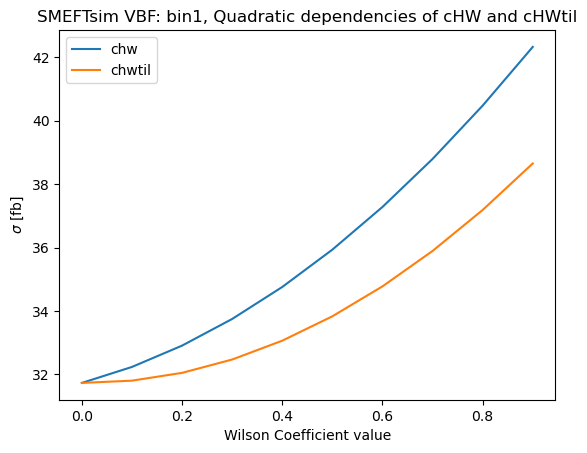

In [89]:
def plot_1D(coeff1, coeff2, coeff3, x_point):
    value = coeff1 * (x_point**2) + coeff2 * (x_point) + coeff3
    return value

###
coffea_name = 'VBF_SMEFTsim_topU3l_NP1'
which_bin = 'bin1'

if which_bin == 'bin1':
    bin_num = 0
elif which_bin == 'bin2':
    bin_num = 1
###

x_chw_vals = np.arange(0, 1, 0.1)
y_chw_vals = np.array([plot_1D(stxs_reweight_function(f'{coffea_name}', ['cHW', 'cHWtil'])[bin_num][0], 
                               stxs_reweight_function(f'{coffea_name}', ['cHW', 'cHWtil'])[bin_num][1],
                               stxs_reweight_function(f'{coffea_name}', ['cHW', 'cHWtil'])[bin_num][-1],
                               x) for x in x_chw_vals])

x_chwtil_vals = np.arange(0, 1, 0.1)
y_chwtil_vals = np.array([plot_1D(stxs_reweight_function(f'{coffea_name}', ['cHW', 'cHWtil'])[bin_num][2],
                                  stxs_reweight_function(f'{coffea_name}', ['cHW', 'cHWtil'])[bin_num][3],
                                  stxs_reweight_function(f'{coffea_name}', ['cHW', 'cHWtil'])[bin_num][-1],
                                  x) for x in x_chwtil_vals])

###
coffea_sumw = util.load(f"coffea/{coffea_name}.coffea")["sumw_all_noEW"]
sumw = coffea_sumw.value

chw_events = y_chw_vals
chwtil_events = y_chwtil_vals

start0_MG_sigma = 3.594
chw_xs_fb = start0_MG_sigma * 1000.0 * (chw_events / sumw)
chwtil_xs_fb = start0_MG_sigma * 1000.0 * (chwtil_events / sumw)

print('chwevents', chw_events)
print(sumw)

plt.title(f'{coffea_name}: {which_bin}, Quadratic dependencies of cHW and cHWtil')
plt.ylabel(r"$\sigma$ [fb]")
plt.xlabel("Wilson Coefficient value")

plt.plot(x_chw_vals, chw_xs_fb, label = 'chw')
plt.plot(x_chwtil_vals, chwtil_xs_fb, label = 'chwtil')
plt.legend()

print(chw_xs_fb[0])
print(chwtil_xs_fb[0])

(100, 100)
SM xsec: 23.262681487383272


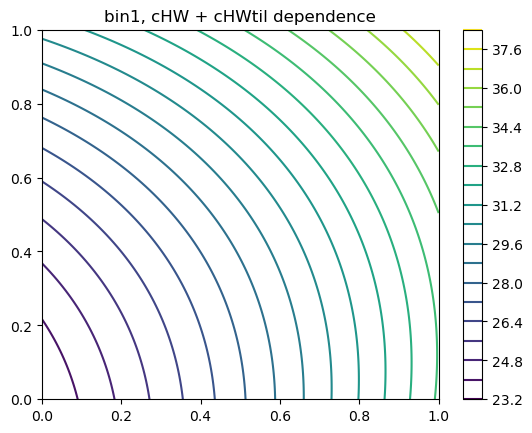

In [21]:
x1_vals = np.linspace(0, 1, 100)
x2_vals = np.linspace(0, 1, 100)

X1, X2 = np.meshgrid(x1_vals, x2_vals)

Z = quad_2D((X1,X2), *coeff_bin1)
print(Z.shape)

Z_xs_fb = start0_MG_sigma * 1000.0 * (Z / sumw)
print("SM xsec:", Z_xs_fb[0, 0])

fig, ax = plt.subplots()
contourplot = plt.contour(x1_vals, x2_vals, Z_xs_fb, levels = 20)

plt.title('bin1, cHW + cHWtil dependence')

cbar = fig.colorbar(contourplot)

def wc_from_name(name):
    #creates dict of wc values from names
    wc = {}
    parts = name.split("_")
    for index, p in enumerate(parts): 
        if p.startswith("c") and index+ 1 < len(parts): #length check to prevent crash at end of parts list
            try:
                wc[p] = float(parts[index+1]) #adds the corresponding value for a given operator (the next part)
            except:
                pass
    return wc

def sample_to_benchmarks(events_root):
    benchmarks = []
    
    f = uproot.open(events_root)
    run_branches = list(f["Runs"].keys())
    
    for k, b in enumerate(run_branches):
        if b.startswith("LHESumw_EFTrwgt"):
            wc = wc_from_name(b)
            benchmarks.append({"index": k,
                               "name": b,
                               "wc": wc})
    return(benchmarks)

def get_2Dfit_points(events_root):
    #returns a list of dicts, one for each benchmark point
    fit_points = []
    
    benchmarks = sample_to_benchmarks(events_root)

    sample_events = NanoEventsFactory.from_root(
        {events_root:"/Events"},
        schemaclass=PFNanoAODSchema,
        mode='eager'
        ).events()
    
    genWeights = sample_events.genWeight
    LHEReweightingWeights = sample_events.LHEReweightingWeight

    for k, bm in enumerate(benchmarks):

        # bin1_mask = 
        # bin2_mask = 
        
        # Y1 = ak.sum(
        #     genWeights[bin1_mask] * LHEReweightingWeights[bin1_mask][:, k]
        # )
        # Y2 = ak.sum(
        #     genWeights[bin2_mask] * LHEReweightingWeights[bin2_mask][:, k]
        # )
        
        bin_yields = {"bin1": 'y1_value', "bin2": 'y2_value'}
        
        point_dict = {"benchmark_index": k,
                      "wc_name": bm['name'],
                      "wc_point": bm['wc'],
                      "yields": bin_yields
                     }
        
        fit_points.append(point_dict)
    return fit_points

print(get_2Dfit_points("/uscms/home/azhou/nobackup/smeft/jennet_files/start0_022526.root"))

def parse_wc_from_name(name):
    #creates dict of wc values from names
    wc = {}
    parts = name.split("_")
    for index, p in enumerate(parts): 
        if p.startswith("c") and index+ 1 < len(parts): #length check to prevent crash at end of parts list
            try:
                wc[p] = float(parts[index+1]) #adds the corresponding value for a given operator (the next part)
            except:
                pass
    return wc


def sample_to_benchmarks(run_branches):
    benchmarks = []
    
    for b in run_branches:
        if b.startswith("LHESumw_EFTrwgt"):
            wc = parse_wc_from_name(b)
            benchmarks.append({
                "name": b,
                "wc": wc
            })
    return(benchmarks)
    print(benchmarks)

#def unique_benchmark_points():
    
sorted(set([bm["wc"]["cHW"] for bm in benchmarks]))
#sorted(set([bm["wc"]["cHWtil"] for bm in benchmarks]))
list_of_cHW_values = sorted(
    set(
        bm["wc"]["cHW"]
        for bm in benchmarks
        if bm["wc"].get("cHW", 0.0) != 0.0
    )
)
#print(list_of_cHW_values)
#print(sorted(set(bm["wc"]["cHW"] for bm in benchmarks)))